In [52]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

from scipy.io import savemat
from collections import OrderedDict
import matplotlib.colors as mcolors

#Main datapaths
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'
#define path for Hawthorne data directory
savepath= dirpath + 'Merge_scripts/'
plots_savepath= dirpath + 'Merge_scripts/plots/'

#Plot formatting
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

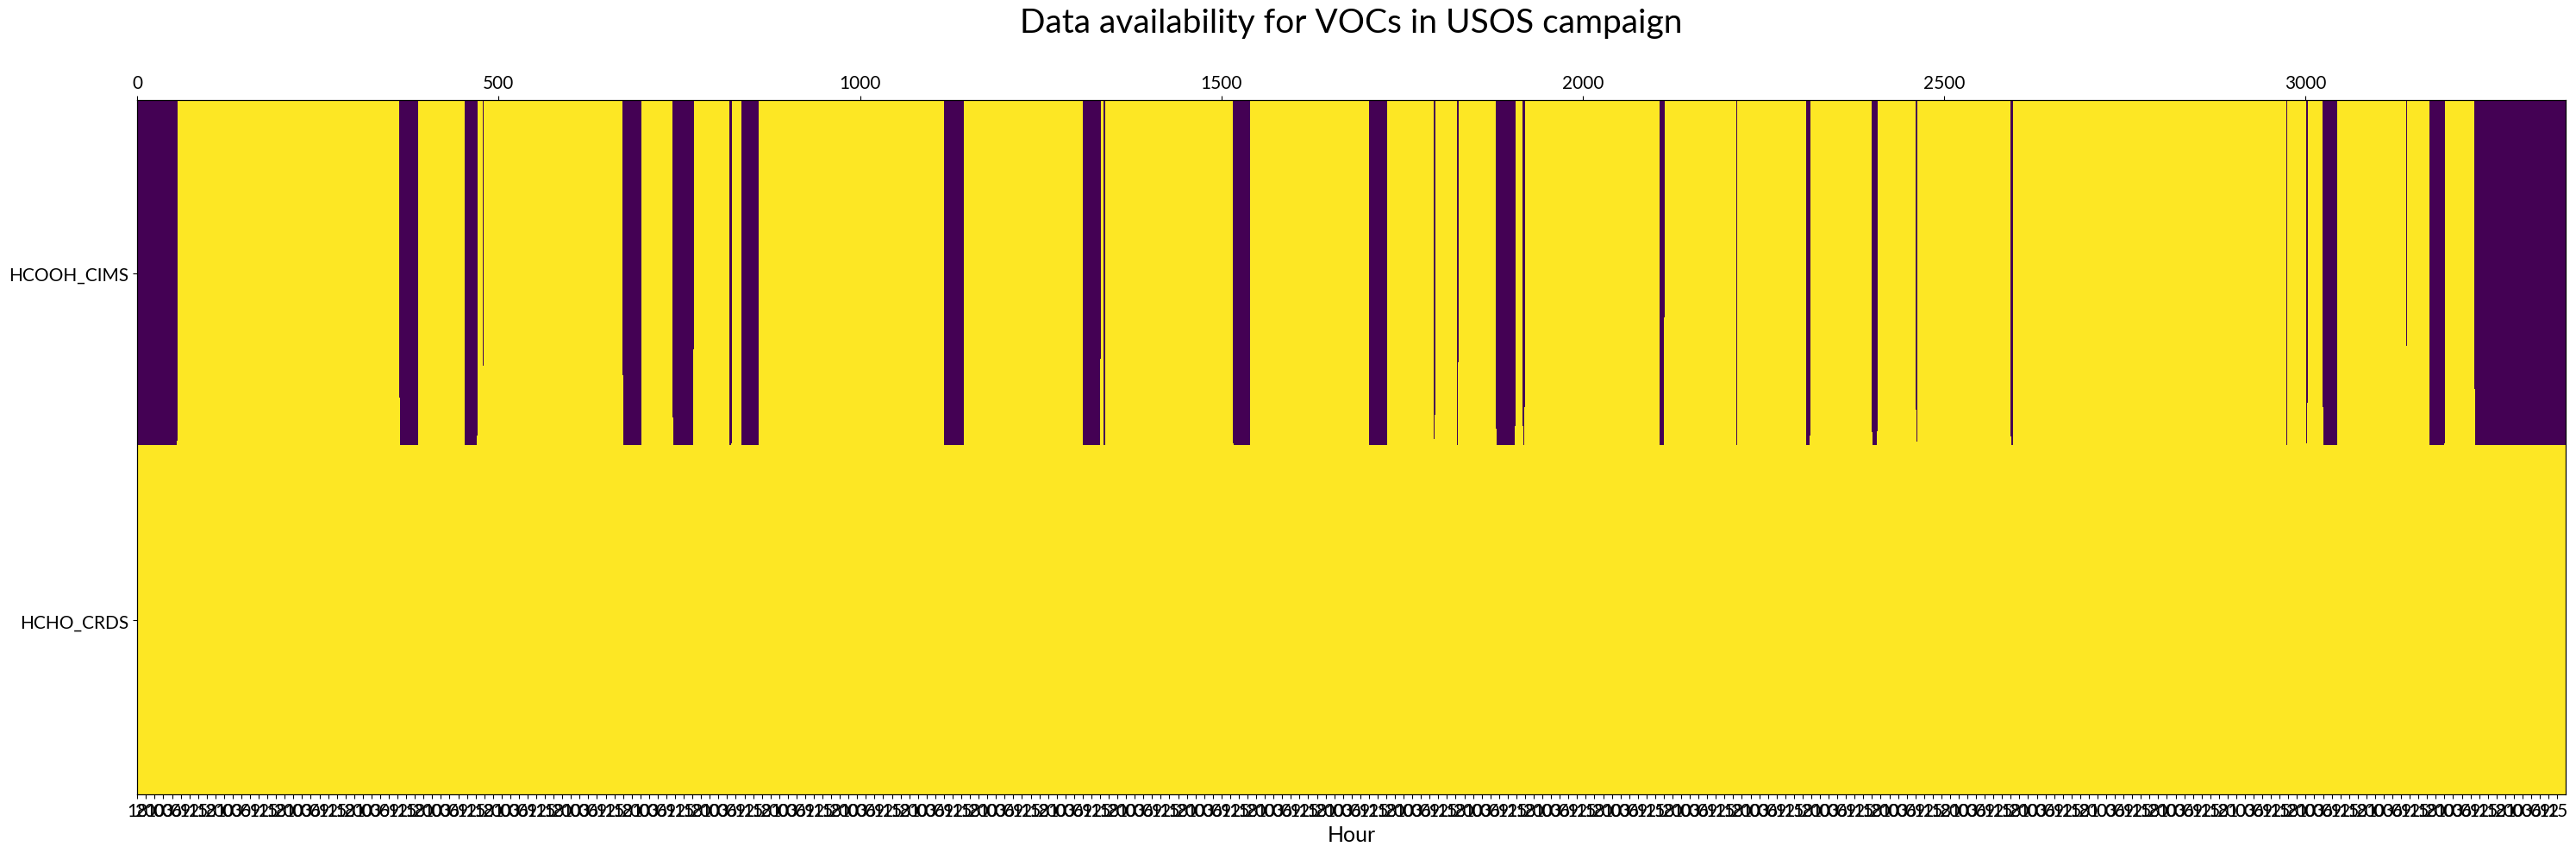

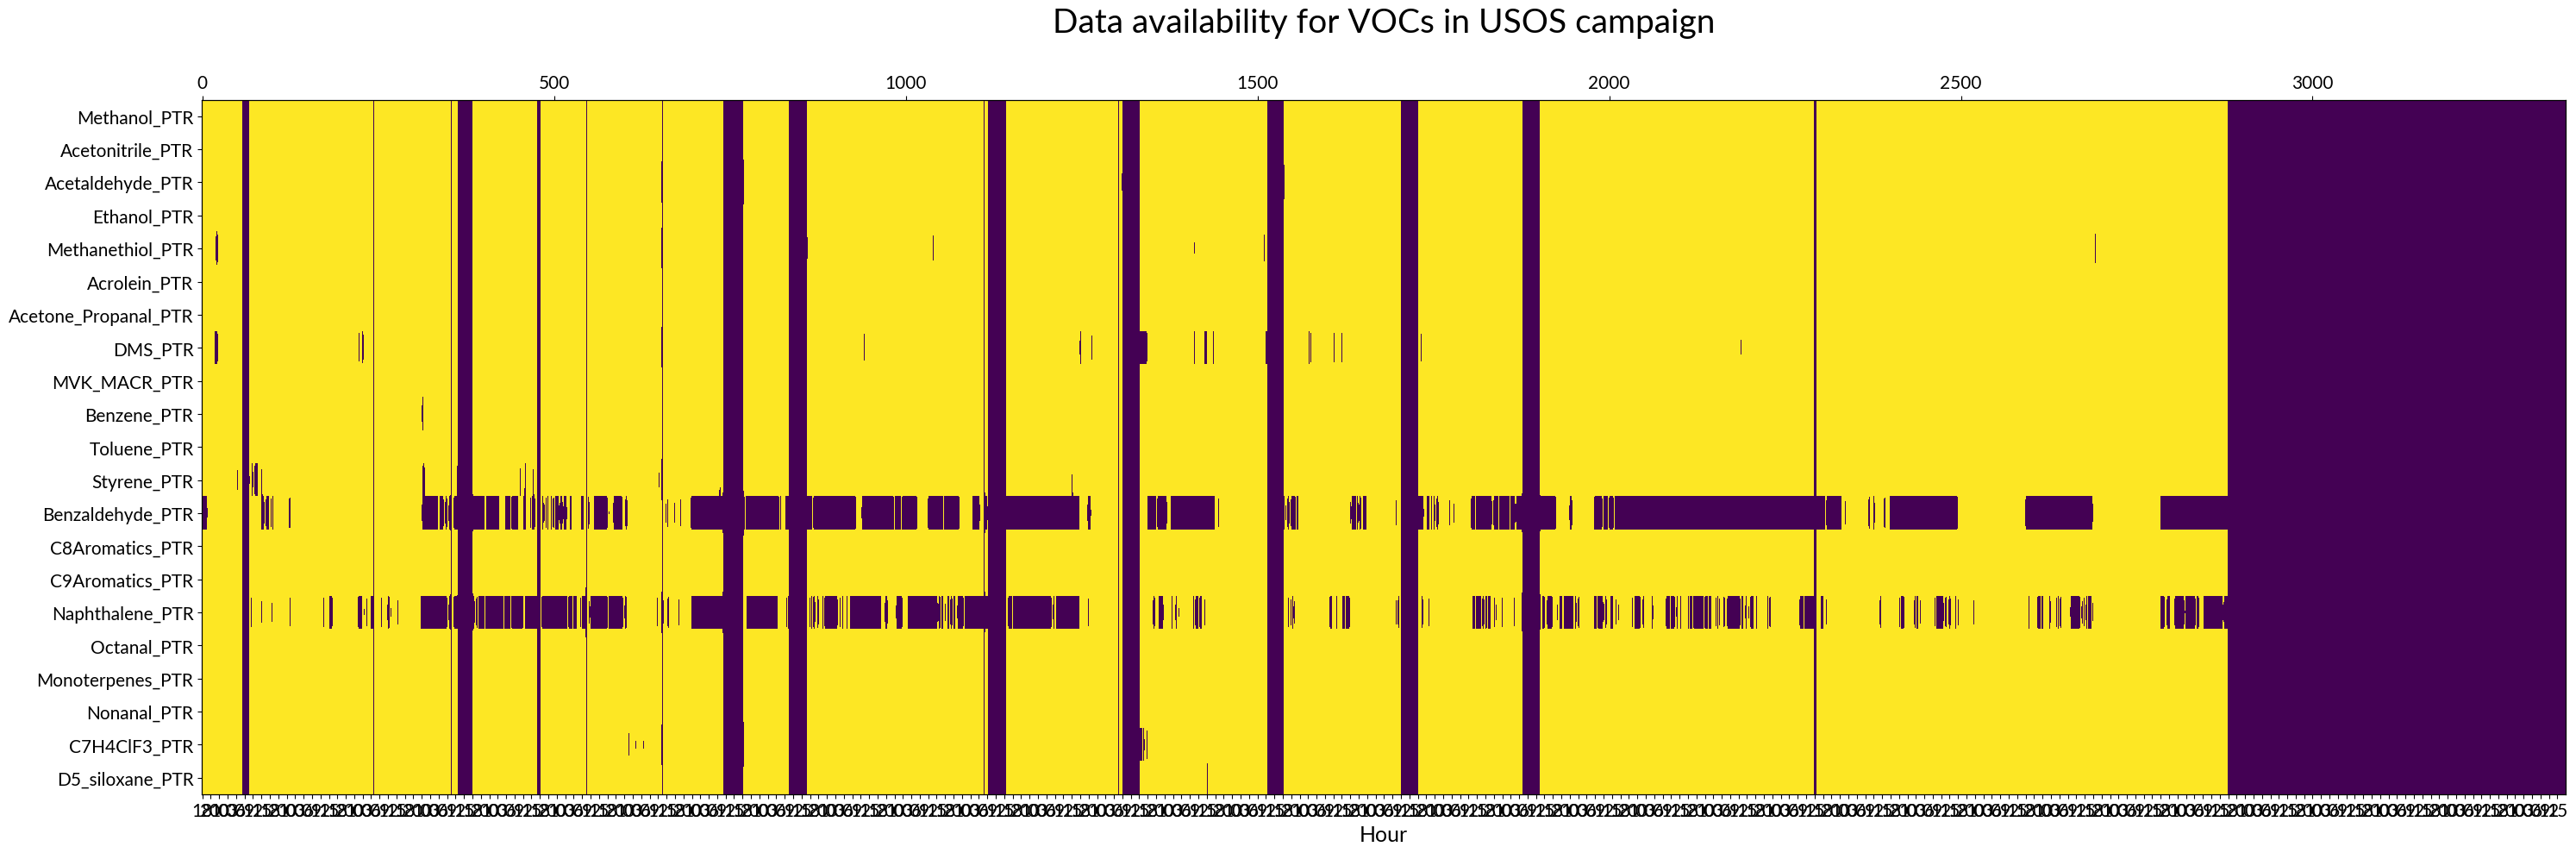

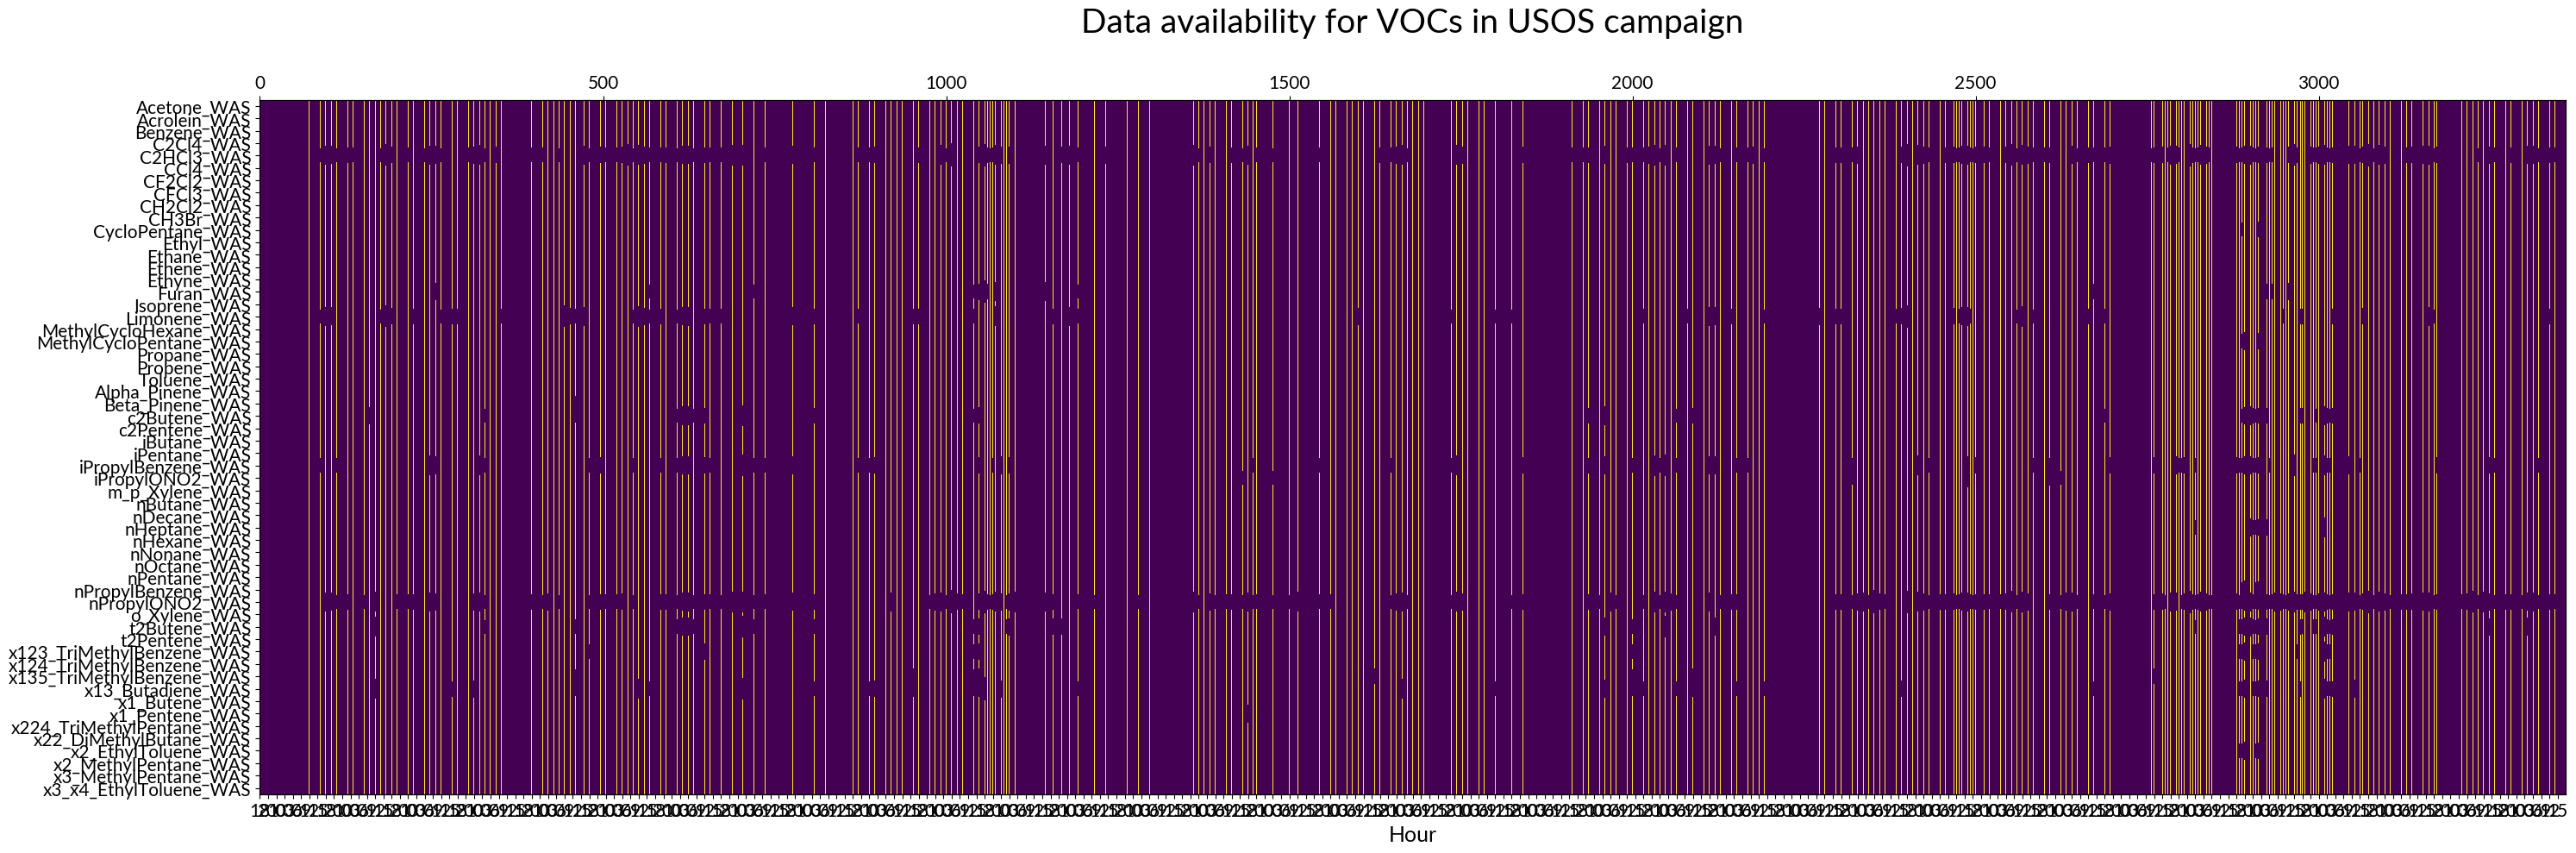

In [29]:
all_days_filepath = '../../CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_15min/all_CSL_MobileLab_Parked_rev15min_iWASupdated_formaldehydeupdated.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.set_index('time_local', inplace=True)
#Identify list of relevant VOCs we want data availability for

misc_list = ['HCOOH_CIMS', 'HCHO_CRDS']

PTR_list = ['Methanol_PTR','Acetonitrile_PTR','Acetaldehyde_PTR','Ethanol_PTR','Methanethiol_PTR','Acrolein_PTR','Acetone_Propanal_PTR','DMS_PTR',
            'MVK_MACR_PTR','Benzene_PTR','Toluene_PTR','Styrene_PTR','Benzaldehyde_PTR','C8Aromatics_PTR','C9Aromatics_PTR','Naphthalene_PTR',
            'Octanal_PTR','Monoterpenes_PTR','Nonanal_PTR','C7H4ClF3_PTR','D5_siloxane_PTR']

WAS_list = ['Acetone_WAS','Acrolein_WAS','Benzene_WAS','C2Cl4_WAS','C2HCl3_WAS','CCl4_WAS','CF2Cl2_WAS','CFCl3_WAS','CH2Cl2_WAS','CH3Br_WAS',
            'CycloPentane_WAS','Ethyl_WAS','Ethane_WAS','Ethene_WAS','Ethyne_WAS','Furan_WAS','Isoprene_WAS','Limonene_WAS',
            'MethylCycloHexane_WAS','MethylCycloPentane_WAS','Propane_WAS','Propene_WAS','Toluene_WAS','Alpha_Pinene_WAS','Beta_Pinene_WAS',
            'c2Butene_WAS','c2Pentene_WAS','iButane_WAS','iPentane_WAS','iPropylBenzene_WAS','iPropylONO2_WAS','m_p_Xylene_WAS','nButane_WAS',
            'nDecane_WAS','nHeptane_WAS','nHexane_WAS','nNonane_WAS','nOctane_WAS','nPentane_WAS','nPropylBenzene_WAS','nPropylONO2_WAS',
            'o_Xylene_WAS','t2Butene_WAS','t2Pentene_WAS','x123_TriMethylBenzene_WAS','x124_TriMethylBenzene_WAS','x135_TriMethylBenzene_WAS',
            'x13_Butadiene_WAS','x1_Butene_WAS','x1_Pentene_WAS','x224_TriMethylPentane_WAS','x22_DiMethylButane_WAS','x2_EthylToluene_WAS',
            'x2_MethylPentane_WAS','x3_MethylPentane_WAS','x3_x4_EthylToluene_WAS']

VOC_list = [misc_list, PTR_list, WAS_list]
df_usos_vocs=pd.DataFrame(index=df_alldays.index)

for instr in VOC_list:
    for col in range(0, len(instr)):
        # Everything that was a NaN or negative is assigned a 0, positive values are assigned a 1
        df_usos_vocs[instr[col]] = np.where((df_alldays[instr[col]] > 0) & (~df_alldays[instr[col]].isna()), 1, 0)
df_usos_vocs_transposed=df_usos_vocs.T

#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[0:2], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[0:2])), labels=df_usos_vocs_transposed.index[0:2])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

#save_filepath_merger = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_merges/data_availability_plots/three_day_availability_'+ str(date_to_plot) + '.png'
#plt.savefig(fname = save_filepath_merger,format='png')
#print('Saved figure as:' + str(save_filepath_merger))

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[2:23], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[2:23])), labels=df_usos_vocs_transposed.index[2:23])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()


# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[23::], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[23::])), labels=df_usos_vocs_transposed.index[23::])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

In [105]:
#removed Naph, Benzaldehyde, npropyl ONO2, C2HCl3 for frequent large gaps
#don't include isoprene PTR due to data issues, use Isoprene WAS instead
#For acetone, there is Acetone + Propanal ('Acetone_Propanal_PTR') from PTR and Acetone from the WAS; keeping the Acetone

VOC_list_with_time = ['HCOOH_CIMS', 'HCHO_CRDS', 'Methanol_PTR','Acetonitrile_PTR','Acetaldehyde_PTR','Ethanol_PTR','Methanethiol_PTR','Acrolein_PTR',
            'DMS_PTR','MVK_MACR_PTR','Benzene_PTR','Toluene_PTR','Styrene_PTR','C8Aromatics_PTR','C9Aromatics_PTR',
            'Octanal_PTR','Monoterpenes_PTR','Nonanal_PTR','C7H4ClF3_PTR','D5_siloxane_PTR','Acetone_WAS','Acrolein_WAS','Benzene_WAS',
            'C2Cl4_WAS','CCl4_WAS','CF2Cl2_WAS','CFCl3_WAS','CH2Cl2_WAS','CH3Br_WAS',
            'CycloPentane_WAS','Ethyl_WAS','Ethane_WAS','Ethene_WAS','Ethyne_WAS','Furan_WAS','Isoprene_WAS','Limonene_WAS',
            'MethylCycloHexane_WAS','MethylCycloPentane_WAS','Propane_WAS','Propene_WAS','Toluene_WAS','Alpha_Pinene_WAS','Beta_Pinene_WAS',
            'c2Butene_WAS','c2Pentene_WAS','iButane_WAS','iPentane_WAS','iPropylBenzene_WAS','iPropylONO2_WAS','m_p_Xylene_WAS','nButane_WAS',
            'nDecane_WAS','nHeptane_WAS','nHexane_WAS','nNonane_WAS','nOctane_WAS','nPentane_WAS','nPropylBenzene_WAS',
            'o_Xylene_WAS','t2Butene_WAS','t2Pentene_WAS','x123_TriMethylBenzene_WAS','x124_TriMethylBenzene_WAS','x135_TriMethylBenzene_WAS',
            'x13_Butadiene_WAS','x1_Butene_WAS','x1_Pentene_WAS','x224_TriMethylPentane_WAS','x22_DiMethylButane_WAS','x2_EthylToluene_WAS',
            'x2_MethylPentane_WAS','x3_MethylPentane_WAS','x3_x4_EthylToluene_WAS', 'time_local']
final_VOC_list = VOC_list_with_time[0:-1]

In [114]:
ml_data = xr.open_dataset('/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_15min/all_CSL_MobileLab_Parked_rev15min_iWASupdated_formaldehydeupdated.nc')
ml_data_vars_subset = ml_data[VOC_list_with_time]
df_ml_data = ml_data_vars_subset.to_dataframe()
df_ml_data.set_index('time_local', inplace=True)

In [116]:
#Turn any negatives into NaNs
for spec in df_ml_data.columns:
    df_ml_data[spec] = df_ml_data[spec].mask(df_ml_data[spec] < 0, np.nan)

#Rename columns to a more common name by using the mappings
#Get names of variables needed from Mobile Lab and UDAQ dataset
mappings_filepath = dirpath + 'Hawthorne_data/mappings/manually_edited/UDAQ_Hawthorne_CRACMM_GEOSCHEM_CB6r5h_mapped_updated_11172025.csv'
df_mapping_parameters = pd.read_csv(mappings_filepath)
df_mapping_parameters = df_mapping_parameters.drop([0]) #drop Total NMVOCs

mapping = dict(zip(df_mapping_parameters['USOS Mapping'], df_mapping_parameters['UDAQ_Variable']))
mapping_func = {k: v for k, v in mapping.items() if not pd.isna(k)}
df_ml_data = df_ml_data.rename(columns=mapping_func)

voc_all_labels = df_ml_data.columns

In [117]:
species_mean_voc = df_ml_data.mean(skipna=True)
print('Mean VOC per species:\n', species_mean_voc, '\n')

mean_total_voc = species_mean_voc.sum()
print('Mean Total VOC:\n', mean_total_voc, '\n')

species_sd_voc = df_ml_data.std(skipna=True)
tvoc_variance = (species_sd_voc**2).sum()
tvoc_std = np.sqrt(tvoc_variance)

print('SD Total VOCs:\n', tvoc_std, '\n')

species_median_voc = df_ml_data.median()
print('Median VOC per species:\n', species_median_voc, '\n')
median_total_voc = species_median_voc.sum()
print('Median Total VOC:\n', median_total_voc, '\n')

species_q25 = df_ml_data.quantile(0.25)
species_q75 = df_ml_data.quantile(0.75)
# Interquartile Range (IQR) Total VOC
iqr_TVOC = species_q75.sum() - species_q25.sum()
print('IQR Total VOC:\n', iqr_TVOC, '\n')


#get percent contributions:
pct_contributions = (species_mean_voc/mean_total_voc)*100
pct_contributions_sorted = pct_contributions.sort_values(ascending=False)


Mean VOC per species:
 HCOOH_CIMS             1.665792
Formaldehyde           2.670934
Methanol_PTR          11.279385
Acetonitrile_PTR       0.286180
Acetaldehyde_PTR       1.850923
                        ...    
x22_Dimethylbutane     0.014403
oEthyltoluene          0.007033
x2_Methylpentane       0.082746
x3_Methylpentane       0.069268
pEthyltoluene          0.026568
Length: 74, dtype: float64 

Mean Total VOC:
 35.1815503197772 

SD Total VOCs:
 7.919497402687516 

Median VOC per species:
 HCOOH_CIMS            1.630378
Formaldehyde          2.516694
Methanol_PTR          9.694714
Acetonitrile_PTR      0.263764
Acetaldehyde_PTR      1.562522
                        ...   
x22_Dimethylbutane    0.009000
oEthyltoluene         0.003000
x2_Methylpentane      0.054000
x3_Methylpentane      0.044000
pEthyltoluene         0.012000
Length: 74, dtype: float64 

Median Total VOC:
 29.083590940042175 

IQR Total VOC:
 20.93087508989365 



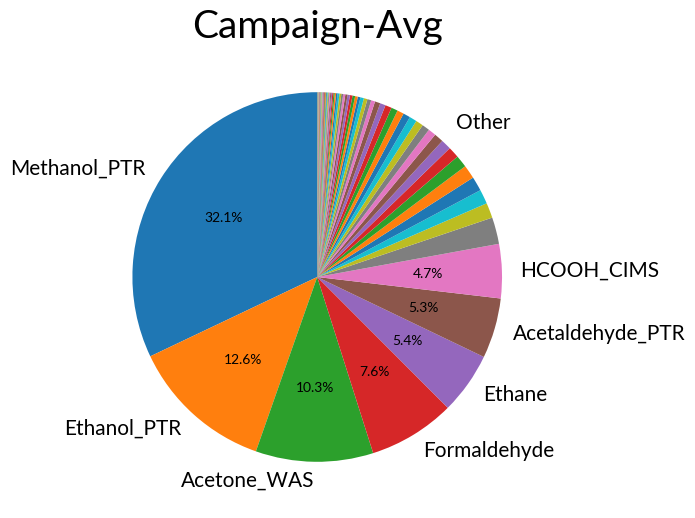

In [118]:
threshold = 3
# Create labels: only show names if contribution >= threshold, else empty string
labels = [car if val >= threshold else '' for car, val in zip(pct_contributions_sorted.index, pct_contributions_sorted)]
# Custom autopct function
def autopct_threshold(pct, threshold=3):
    return f'{pct:.1f}%' if pct >= threshold else ''  # Show label only if >= threshold

plt.figure(figsize=(6,6))
plt.pie(
    pct_contributions_sorted,
    labels=labels,
    autopct=lambda pct: autopct_threshold(pct, threshold=3),
    startangle=90
)

# Add a single 'Other' annotation
plt.annotate(
    'Other', 
    xy=(0, 0),  # Center of the pie chart
    xytext=(0.9, 0.8),  # Position text below the pie
    ha='center', 
    fontsize=15
)
plt.title('Campaign-Avg')
plt.show()


In [110]:
print(pct_contributions_sorted)

Methanol_PTR             32.060511
Ethanol_PTR              12.556989
Acetone_WAS              10.280104
Formaldehyde              7.591859
Ethane                    5.391547
                           ...    
oEthyltoluene             0.019989
x123_Trimethylbenzene     0.018755
Limonene_WAS              0.013338
Isopropylbenzene          0.011121
Methanethiol_PTR          0.010515
Length: 74, dtype: float64


/tmp/ipykernel_1605956/930754950.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


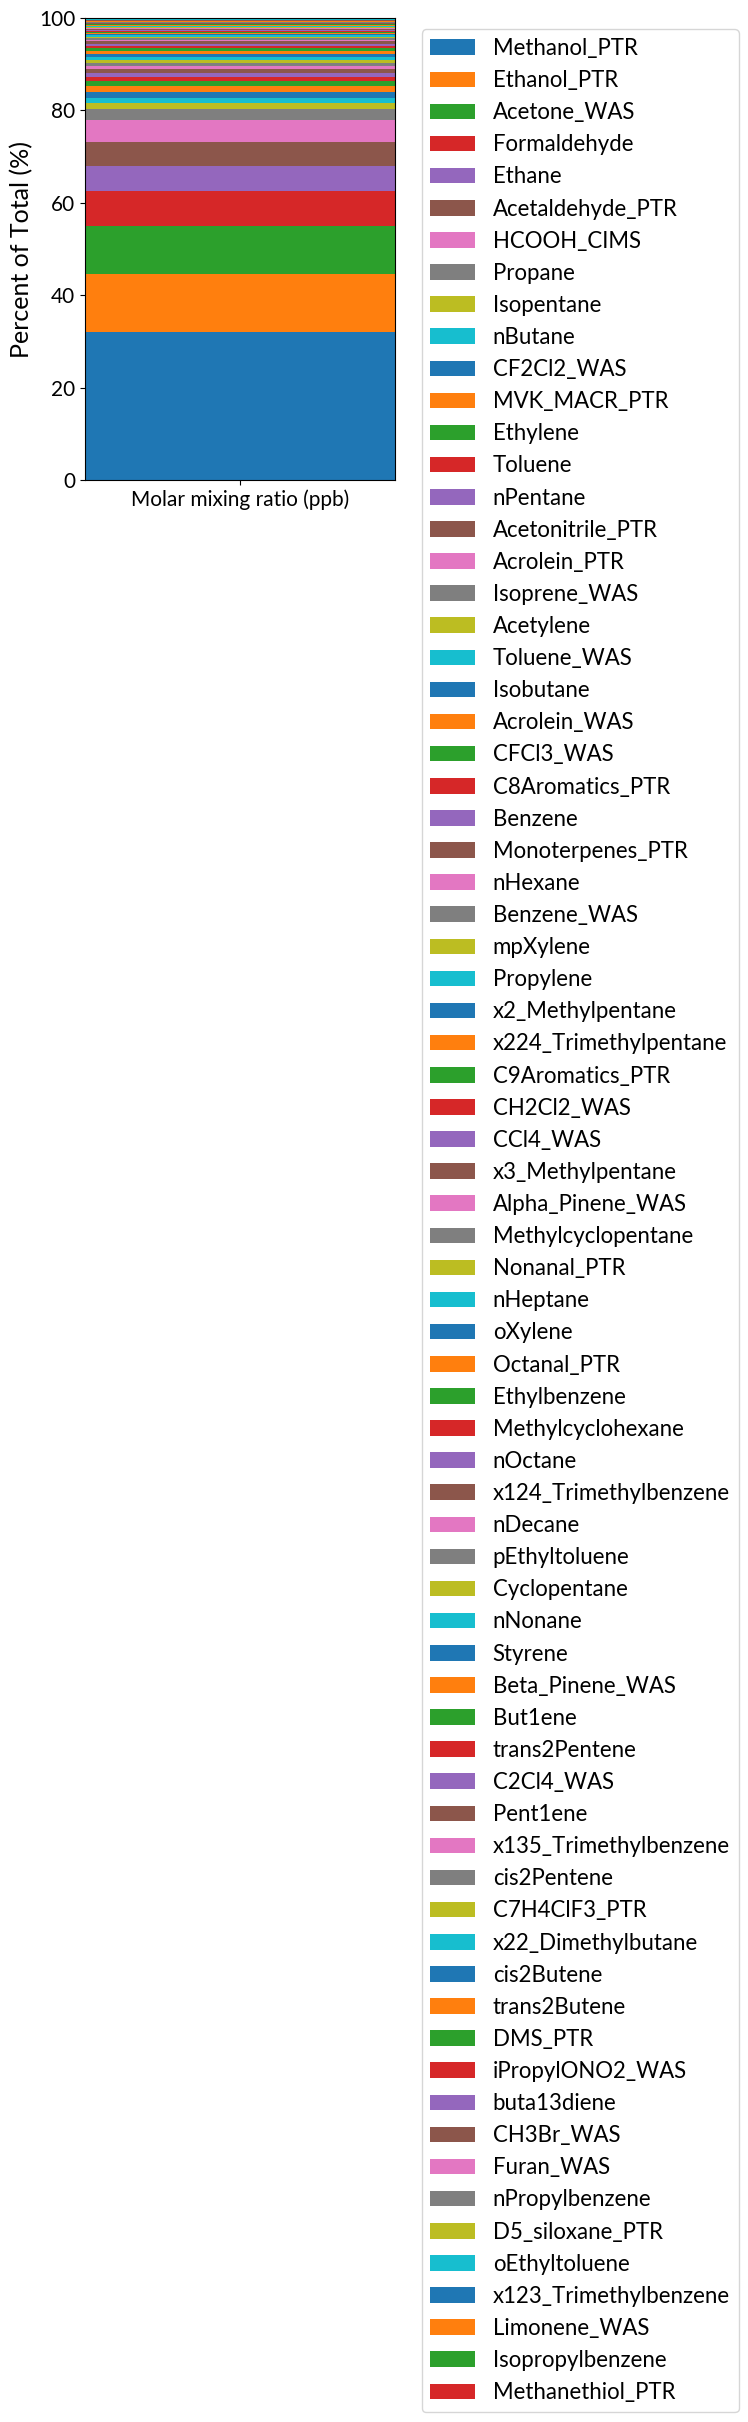

In [119]:
bottom = 0

plt.figure(figsize=(4, 6))

for species, value in pct_contributions_sorted.items():
    plt.bar(
        x=0,                 # single bar
        height=value,
        bottom=bottom,
        label=species
    )
    bottom += value

plt.ylabel('Percent of Total (%)')
plt.xticks([0], ['Molar mixing ratio (ppb)'])
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.title('VOC Composition')

plt.tight_layout()
plt.show()

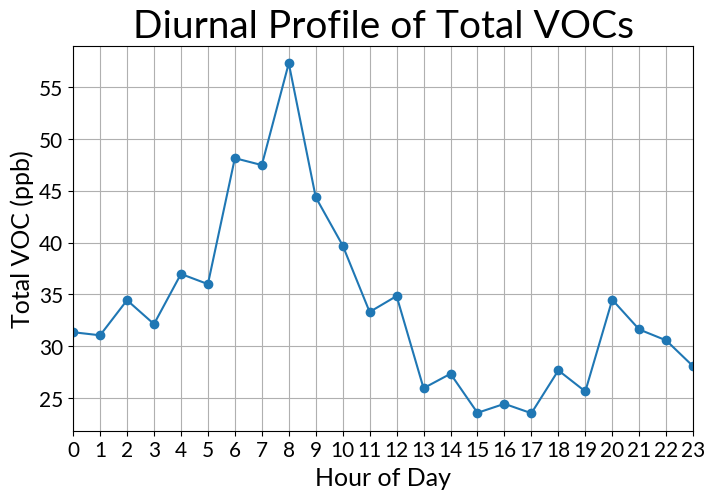

In [120]:
#Put data into hour-of-day bin
df_ml_data['hour'] = df_ml_data.index.hour
#Group by hour and take mean per species
hourly_means = df_ml_data.groupby('hour')[voc_all_labels].mean()
#Sum to get total VOC
hourly_means['TVOC'] = hourly_means.sum(axis=1)
plt.figure(figsize=(8,5))
plt.plot(hourly_means.index, hourly_means['TVOC'], marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Total VOC (ppb)')
plt.title('Diurnal Profile of Total VOCs')
plt.grid(True)
plt.xticks(range(0,24))
plt.show()

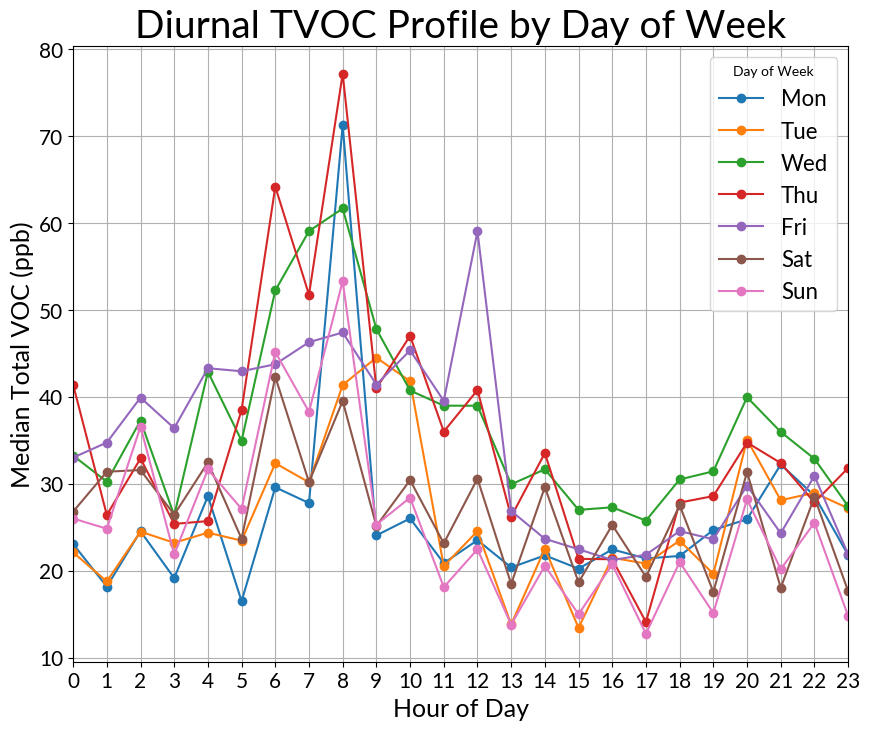

Avg of Median TVOC: 
 Mon    25.593593
Tue    26.089662
Wed    36.841479
Thu    35.328811
Fri    34.341750
Sat    26.896431
Sun    25.277656
dtype: float64 

SD of Median TVOC: 
 Mon    10.233516
Tue     7.943919
Wed     9.721740
Thu    13.667419
Fri    10.287487
Sat     6.503155
Sun     9.803892
dtype: float64


In [121]:
df_ml_data['dayofweek'] = df_ml_data.index.dayofweek
hourly_dow_medians = df_ml_data.groupby(['dayofweek','hour'])[voc_all_labels].median()
#Total VOC
hourly_dow_medians['TVOC'] = hourly_dow_medians.sum(axis=1)

# Create a pivot table: rows=hour, columns=day of week
tvoc_pivot = hourly_dow_medians['TVOC'].unstack(level=0)  # columns are days of week
tvoc_pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(10,8))
for day in tvoc_pivot.columns:
    plt.plot(tvoc_pivot.index, tvoc_pivot[day], marker='o', label=f'{day}')
plt.xlabel('Hour of Day')
plt.ylabel('Median Total VOC (ppb)')
plt.title('Diurnal TVOC Profile by Day of Week')
plt.legend(title='Day of Week')
plt.grid(True)
plt.xticks(range(0,24))
plt.show()

print('Avg of Median TVOC: \n', tvoc_pivot.mean(axis=0), '\n')
print('SD of Median TVOC: \n', np.std(tvoc_pivot, axis=0))

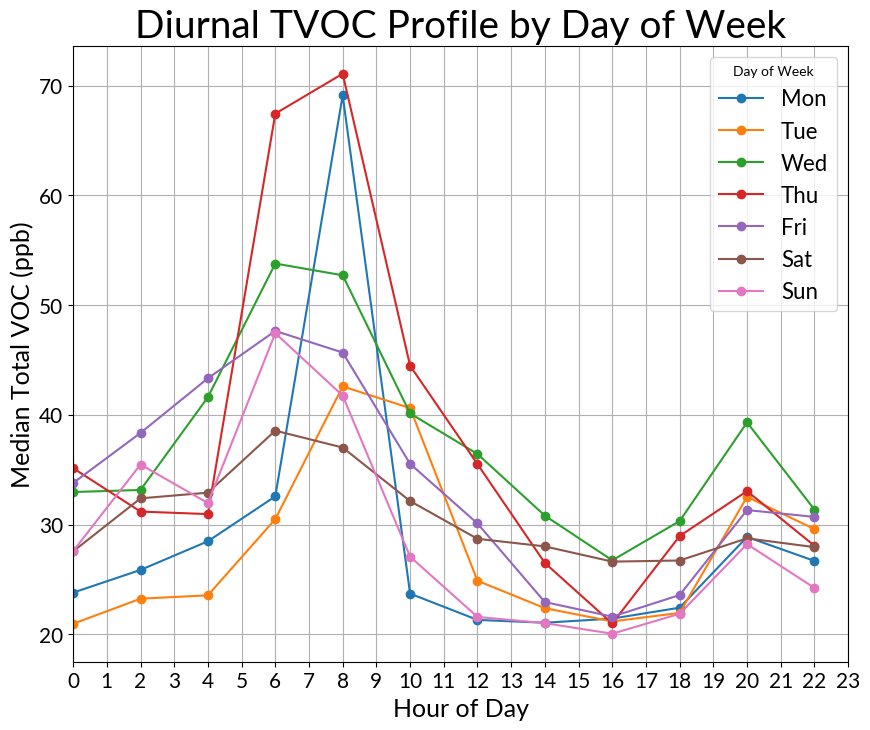

Avg of Median TVOC: 
 Mon    28.776290
Tue    27.829297
Wed    37.447051
Thu    37.781481
Fri    33.715931
Sat    30.609943
Sun    29.019916
dtype: float64 

SD of Median TVOC: 
 Mon    12.635925
Tue     7.175082
Wed     8.238969
Thu    15.115788
Fri     8.407561
Sat     3.834517
Sun     8.329407
dtype: float64


In [150]:
df_ml_data['hour_2h'] = (df_ml_data.index.hour // 2) * 2

df_ml_data['dayofweek'] = df_ml_data.index.dayofweek
bihourly_dow_medians = df_ml_data.groupby(['dayofweek','hour_2h'])[voc_all_labels].median()
#Total VOC
bihourly_dow_medians['TVOC'] = bihourly_dow_medians.sum(axis=1)

# Create a pivot table: rows=hour, columns=day of week
bihourly_tvoc_pivot = bihourly_dow_medians['TVOC'].unstack(level=0)  # columns are days of week
bihourly_tvoc_pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(10,8))
for day in bihourly_tvoc_pivot.columns:
    plt.plot(bihourly_tvoc_pivot.index, bihourly_tvoc_pivot[day], marker='o', label=f'{day}')
plt.xlabel('Hour of Day')
plt.ylabel('Median Total VOC (ppb)')
plt.title('Diurnal TVOC Profile by Day of Week')
plt.legend(title='Day of Week')
plt.grid(True)
plt.xticks(range(0,24))
plt.show()

print('Avg of Median TVOC: \n', bihourly_tvoc_pivot.mean(axis=0), '\n')
print('SD of Median TVOC: \n', np.std(bihourly_tvoc_pivot, axis=0))

/uufs/chpc.utah.edu/common/home/u1545774/MySoftware/micromamba/envs/phdresearch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


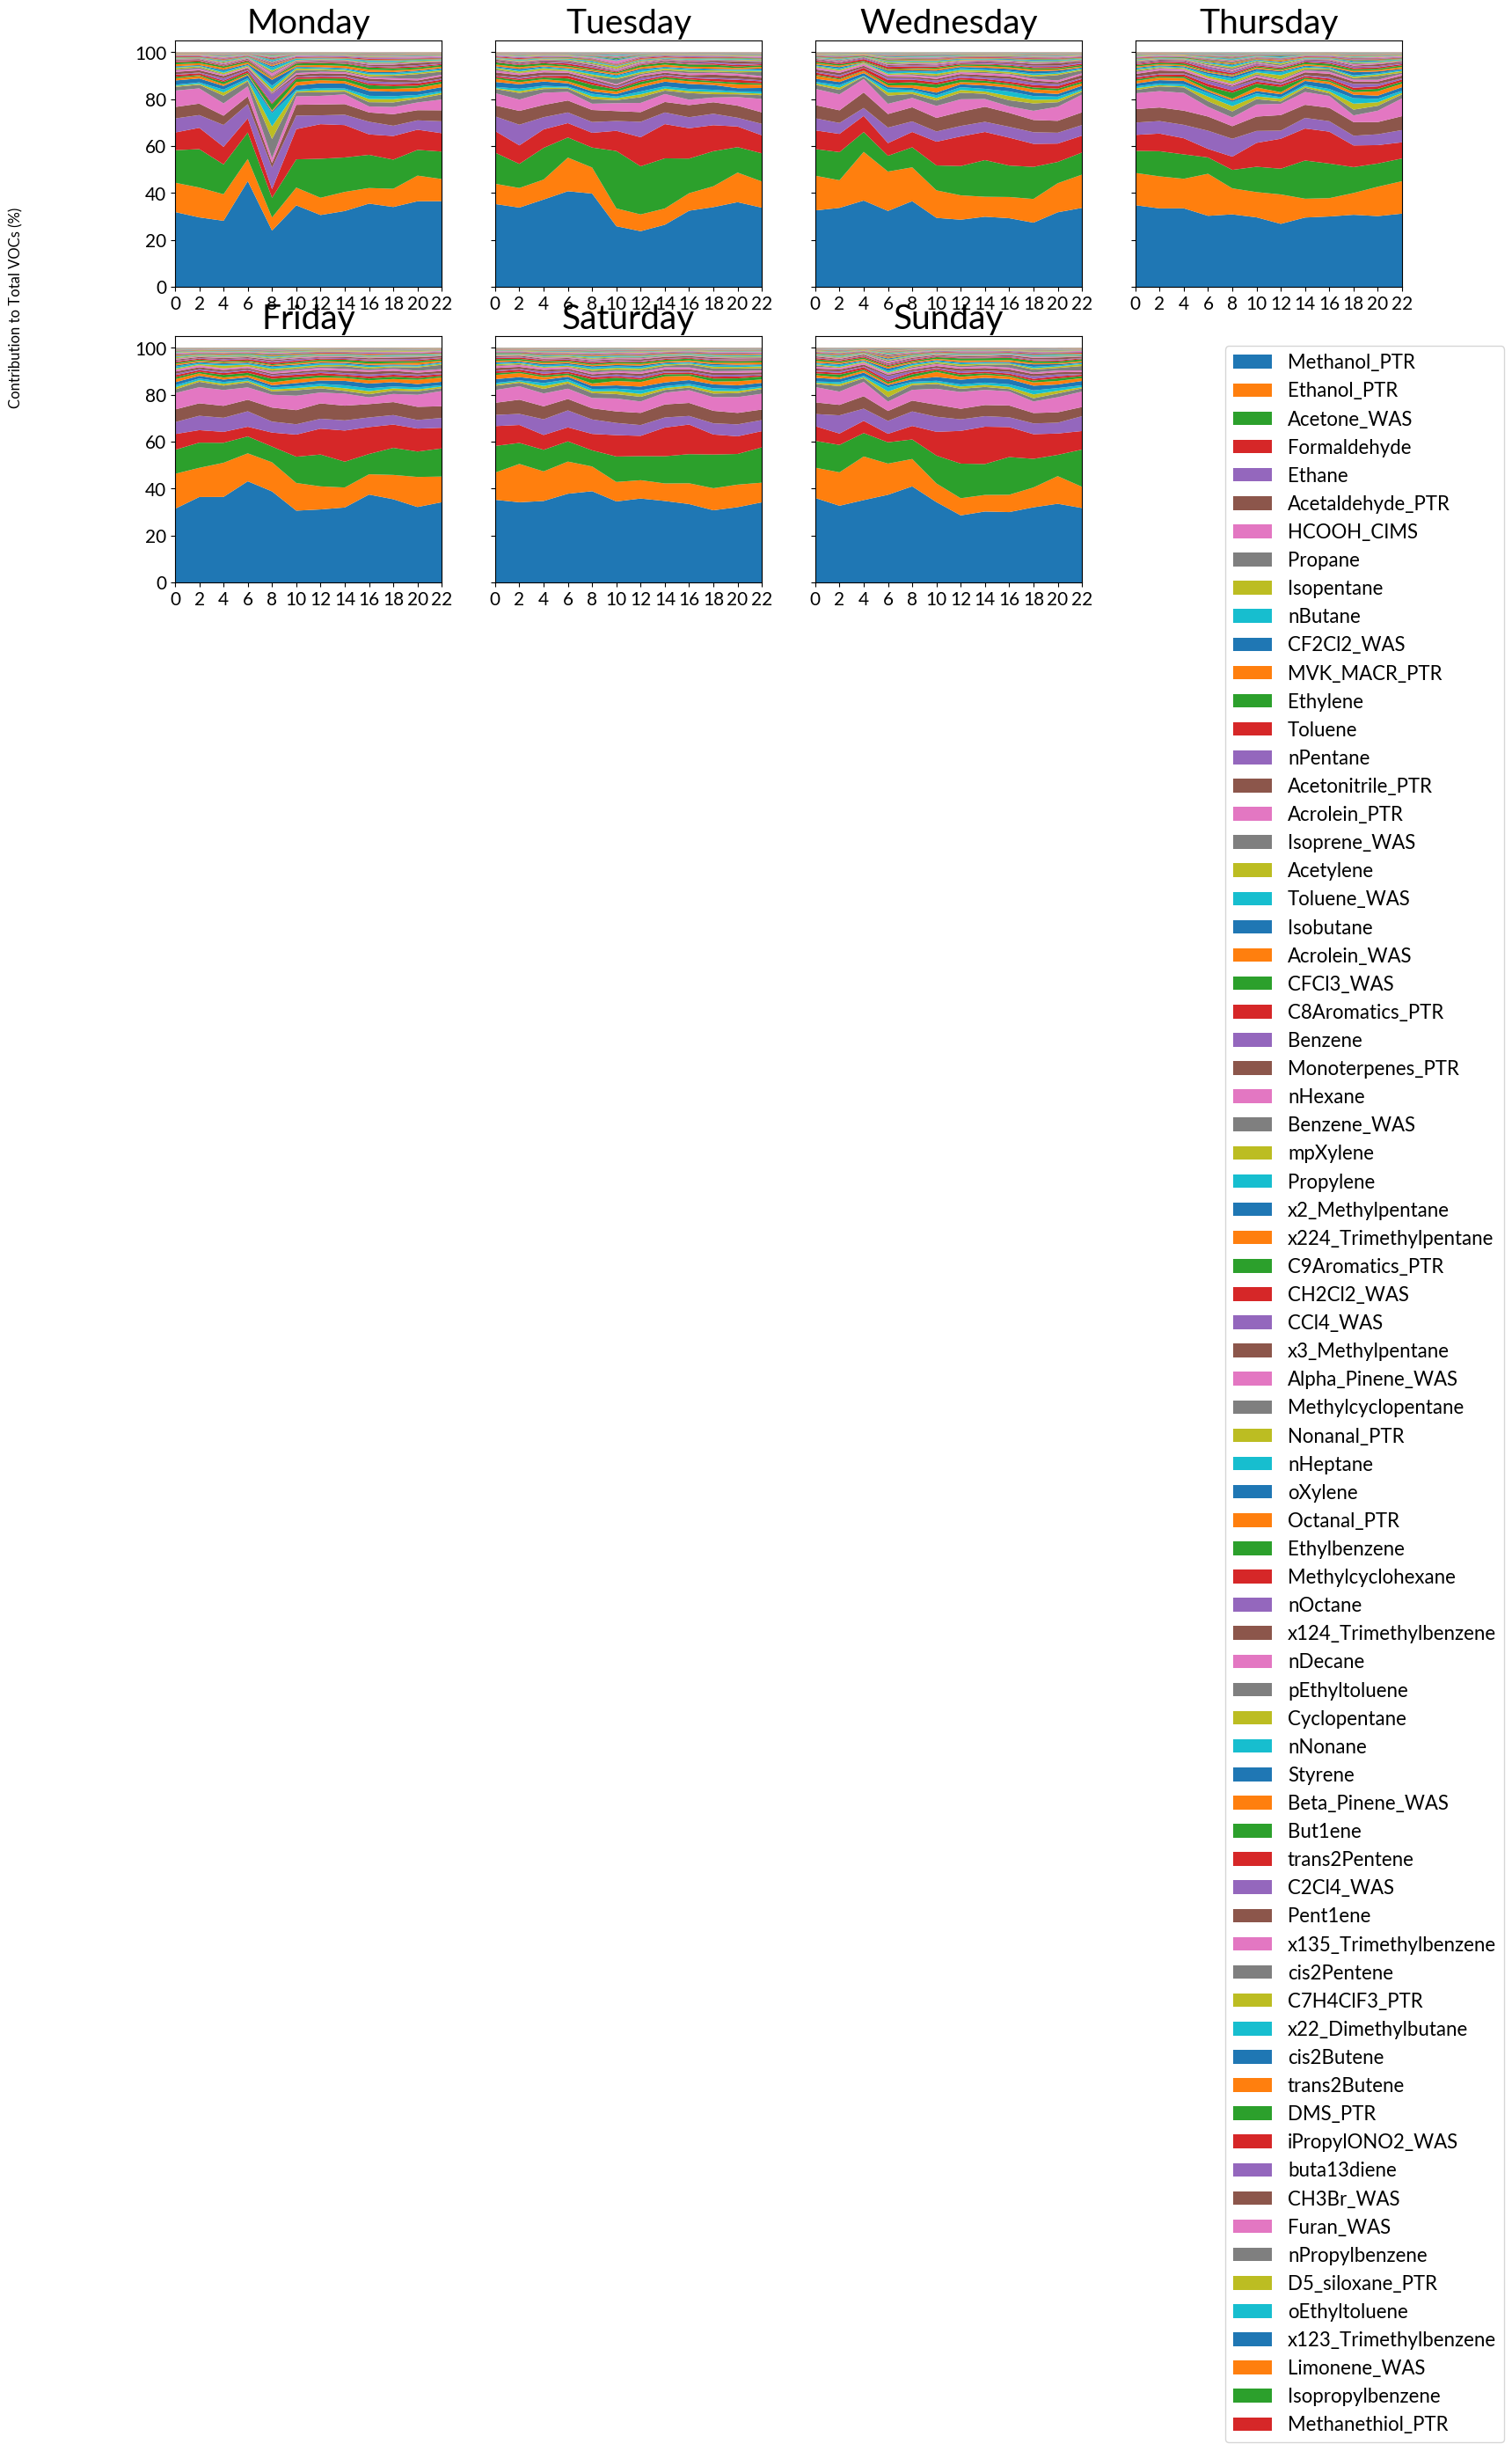

In [180]:
#bihourly_dow_medians = bihourly_dow_medians.drop(columns = 'TVOC')

mon_bihourly_data = bihourly_dow_medians.loc[0]
df_percent_mon = mon_bihourly_data.div(mon_bihourly_data.sum(axis=1), axis=0) * 100
mean_percent_mon = df_percent_mon.mean(axis=0)
species_order_mon = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_mon = df_percent_mon[species_order_mon]

tues_bihourly_data = bihourly_dow_medians.loc[1]
df_percent_tues = tues_bihourly_data.div(tues_bihourly_data.sum(axis=1), axis=0) * 100
species_order_tues = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_tues = df_percent_tues[species_order_tues]

wed_bihourly_data = bihourly_dow_medians.loc[2]
df_percent_wed = wed_bihourly_data.div(wed_bihourly_data.sum(axis=1), axis=0) * 100
species_order_wed = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_wed = df_percent_wed[species_order_wed]

thurs_bihourly_data = bihourly_dow_medians.loc[3]
df_percent_thurs = thurs_bihourly_data.div(thurs_bihourly_data.sum(axis=1), axis=0) * 100
species_order_thurs = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_thurs = df_percent_thurs[species_order_thurs]

fri_bihourly_data = bihourly_dow_medians.loc[4]
df_percent_fri = fri_bihourly_data.div(fri_bihourly_data.sum(axis=1), axis=0) * 100
species_order_fri = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_fri = df_percent_fri[species_order_fri]

sat_bihourly_data = bihourly_dow_medians.loc[5]
df_percent_sat = sat_bihourly_data.div(sat_bihourly_data.sum(axis=1), axis=0) * 100
species_order_sat = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_sat = df_percent_sat[species_order_sat]

sun_bihourly_data = bihourly_dow_medians.loc[6]
df_percent_sun = sun_bihourly_data.div(sun_bihourly_data.sum(axis=1), axis=0) * 100
species_order_sun = pct_contributions_sorted.sort_values(ascending=False).index
df_percent_sorted_sun = df_percent_sun[species_order_sun]

bihour_range = np.arange(0,24,2)
contr_transposed_mon= df_percent_sorted_mon.T.values
contr_transposed_tues= df_percent_sorted_tues.T.values
contr_transposed_wed= df_percent_sorted_wed.T.values
contr_transposed_thurs= df_percent_sorted_thurs.T.values
contr_transposed_fri= df_percent_sorted_fri.T.values
contr_transposed_sat= df_percent_sorted_sat.T.values
contr_transposed_sun= df_percent_sorted_sun.T.values

fig, axs = plt.subplots(2,4, figsize = (18,8), tight_layout=True, sharey=True, sharex=True)
axs[0, 0].stackplot(bihour_range, contr_transposed_mon)
axs[0, 0].set_title("Monday")
axs[0, 0].set_xticks(np.arange(0, 24, 2))
axs[0, 0].tick_params(axis='x', labelbottom = True)

axs[0, 1].stackplot(bihour_range, contr_transposed_tues)
axs[0, 1].set_title("Tuesday")
axs[0, 1].tick_params(axis='x', labelbottom = True)

axs[0, 2].stackplot(bihour_range, contr_transposed_wed)
axs[0, 2].set_title("Wednesday")
axs[0, 2].tick_params(axis='x', labelbottom = True)

axs[0, 3].stackplot(bihour_range, contr_transposed_thurs)
axs[0, 3].set_title("Thursday")
axs[0, 3].tick_params(axis='x', labelbottom = True)

axs[1, 0].stackplot(bihour_range, contr_transposed_fri)
axs[1, 0].set_title("Friday")
axs[1, 0].tick_params(axis='x', labelbottom = True)

axs[1, 1].stackplot(bihour_range, contr_transposed_sat)
axs[1, 1].set_title("Saturday")
axs[1, 1].tick_params(axis='x', labelbottom = True)

axs[1, 2].stackplot(bihour_range, contr_transposed_sun)
axs[1, 2].set_title("Sunday")
axs[1, 2].tick_params(axis='x', labelbottom = True)
fig.delaxes(axs[1, 3])

ax.tick_params(axis='x', labelbottom = True)

fig.supylabel('Contribution to Total VOCs (%)')
axs[1, 2].legend(labels = df_percent_sorted_sun.columns,bbox_to_anchor=(1.5, 1))
plt.show()

/tmp/ipykernel_1605956/716083294.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_1605956/716083294.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


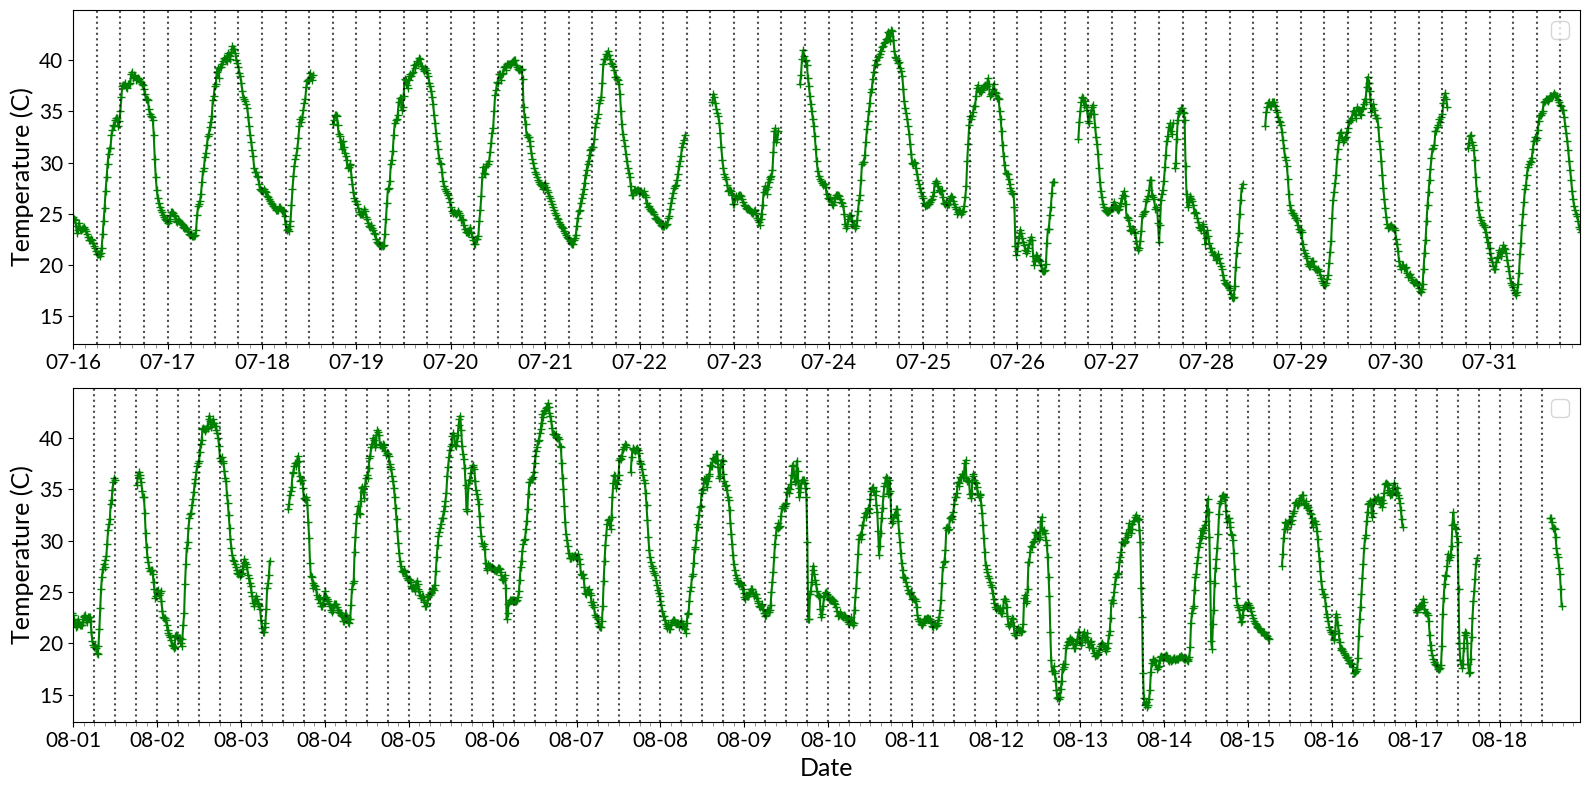

In [188]:
df_alldays['Temp_C'] = df_alldays['Temp_K']-273.25

fig, (ax1, ax2) = plt.subplots(2,1, figsize = (16,8), tight_layout=True)

species_name_var = 'Temperature'
species_unit = '(C)'
xlim_start_jul = pd.to_datetime('2024-07-16 00:00:00')
xlim_end_jul = pd.to_datetime('2024-07-31 23:00:00')

#ax1 is the first row of subplot, for July only
ax1.plot(df_alldays.index, df_alldays['Temp_C'], linestyle = 'solid', color = 'g', marker = '+')

#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_alldays.index),24):
    midnight_vals.append(df_alldays.index[midnight_idx])
for day_pos in midnight_vals:
    ax1.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

#Set x ticks
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax1.tick_params(axis='x', which='major')
ax1.tick_params(axis='x', which='minor', length=3, color='gray')

ax1.set_ylabel(species_name_var + ' ' + species_unit)
#ax1.set_xlabel('Date')
ax1.margins(x=0)
ax1.set_xlim([xlim_start_jul, xlim_end_jul])

ax1.legend()

#ax2 is the second row of subplot, for August only
ax2.plot(df_alldays.index, df_alldays['Temp_C'], linestyle = 'solid', color = 'g', marker = '+')

#Mark midnight for every day
midnight_vals = []
for midnight_idx in range(0,len(df_alldays.index),24):
    midnight_vals.append(df_alldays.index[midnight_idx])
for day_pos in midnight_vals:
    ax2.axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

#Set x ticks
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 3 hours
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
# Rotate and format tick labels
ax2.tick_params(axis='x', which='major')
ax2.tick_params(axis='x', which='minor', length=3, color='gray')

ax2.set_ylabel(species_name_var + ' ' + species_unit)
ax2.set_xlabel('Date')
ax2.margins(x=0)

ax2.set_xlim([pd.to_datetime('2024-08-01 00:00:00'), pd.to_datetime('2024-08-18 23:00:00')])
ax2.legend()
plt.show()
